# Notebook 09: Lesion Grounding and Visible Severity Proxy

This notebook estimates a visible lesion-area severity proxy from PlantVillage leaf images.

## Scope

The PlantVillage labels identify crop and disease class, but do not provide expert
severity-stage annotations. Therefore, this notebook does **not** claim clinical
or agronomic disease-stage prediction.

Instead, it:

1. Obtains a leaf-region mask using image-background separation.
2. Estimates discoloured/necrotic lesion pixels within the leaf region.
3. Computes a visible lesion-area ratio.
4. Maps the ratio into descriptive proxy bands:
   - Mild
   - Moderate
   - Severe
5. Produces qualitative panels and a reproducible severity manifest.

The resulting value is a computer-vision severity proxy and must be externally
validated before any field-deployment or agronomic-management claim.

In [1]:
import os
import json
import random
import platform
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image, ImageFile
from tqdm.auto import tqdm

import cv2
from scipy import ndimage
from scipy.stats import (
    spearmanr,
    pearsonr
)

ImageFile.LOAD_TRUNCATED_IMAGES = True

SEED = 7

random.seed(SEED)
np.random.seed(SEED)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:.5f}")

print("OpenCV:", cv2.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

OpenCV: 4.13.0
NumPy: 2.0.2
Pandas: 2.3.3


In [2]:
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 12,

    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "axes.linewidth": 1.2,

    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,

    "legend.fontsize": 11,
    "legend.frameon": True,
    "legend.edgecolor": "0.4",

    "grid.linestyle": ":",
    "grid.linewidth": 0.7,
    "grid.alpha": 0.85,
})


def paper_axes(ax):
    ax.minorticks_on()

    ax.grid(
        True,
        which="major",
        linestyle=":",
        linewidth=0.8
    )

    ax.grid(
        True,
        which="minor",
        linestyle=":",
        linewidth=0.5,
        alpha=0.7
    )

    for spine in ax.spines.values():
        spine.set_linewidth(1.2)

    ax.tick_params(
        which="both",
        direction="in",
        top=True,
        right=True
    )


print("Professional paper plotting style enabled.")

Professional paper plotting style enabled.


In [3]:
INPUT_ROOT = Path("/kaggle/input")
WORK_DIR = Path("/kaggle/working")

OUTPUT_DIR = WORK_DIR / "lesion_grounding_severity_proxy_outputs"
FIG_DIR = OUTPUT_DIR / "figures"
MASK_DIR = OUTPUT_DIR / "masks"
TABLE_DIR = OUTPUT_DIR / "tables"
METADATA_DIR = OUTPUT_DIR / "metadata"

for folder in [
    OUTPUT_DIR,
    FIG_DIR,
    MASK_DIR,
    TABLE_DIR,
    METADATA_DIR
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Input root:", INPUT_ROOT)
print("Output directory:", OUTPUT_DIR)

Input root: /kaggle/input
Output directory: /kaggle/working/lesion_grounding_severity_proxy_outputs


In [4]:
def find_input_file(file_name):
    matches = list(INPUT_ROOT.rglob(file_name))

    if len(matches) == 0:
        raise FileNotFoundError(
            f"Could not locate '{file_name}' under /kaggle/input."
        )

    if len(matches) > 1:
        print(f"Multiple matches for {file_name}:")
        for match in matches:
            print(" -", match)

        print("Using:", matches[0])

    return matches[0]


TRAIN_MANIFEST_PATH = find_input_file(
    "main19_train.csv"
)

CALIBRATION_MANIFEST_PATH = find_input_file(
    "main19_calibration.csv"
)

TEST_MANIFEST_PATH = find_input_file(
    "main19_internal_test.csv"
)

CLASS_MAPPING_PATH = find_input_file(
    "class_to_index_main19.json"
)

print("Train manifest:", TRAIN_MANIFEST_PATH)
print("Calibration manifest:", CALIBRATION_MANIFEST_PATH)
print("Internal-test manifest:", TEST_MANIFEST_PATH)
print("Class mapping:", CLASS_MAPPING_PATH)

Train manifest: /kaggle/input/datasets/katakuricharlotte/crop-manifestfiles/split_outputs/split_outputs/manifests/main19/main19_train.csv
Calibration manifest: /kaggle/input/datasets/katakuricharlotte/crop-manifestfiles/split_outputs/split_outputs/manifests/main19/main19_calibration.csv
Internal-test manifest: /kaggle/input/datasets/katakuricharlotte/crop-manifestfiles/split_outputs/split_outputs/manifests/main19/main19_internal_test.csv
Class mapping: /kaggle/input/datasets/katakuricharlotte/crop-manifestfiles/split_outputs/split_outputs/metadata/class_to_index_main19.json


In [5]:
train_df = pd.read_csv(TRAIN_MANIFEST_PATH)
calibration_df = pd.read_csv(CALIBRATION_MANIFEST_PATH)
test_df = pd.read_csv(TEST_MANIFEST_PATH)

with open(CLASS_MAPPING_PATH, "r") as file:
    class_to_index = json.load(file)

all_main19_df = pd.concat(
    [
        train_df,
        calibration_df,
        test_df
    ],
    ignore_index=True
)

assert all_main19_df["label"].nunique() == 19
assert all_main19_df["image_path"].nunique() == len(all_main19_df)

print("Train images:", len(train_df))
print("Calibration images:", len(calibration_df))
print("Internal-test images:", len(test_df))
print("Total Main19 images:", len(all_main19_df))
print("Classes:", all_main19_df["label"].nunique())

Train images: 18113
Calibration images: 3197
Internal-test images: 5322
Total Main19 images: 26632
Classes: 19


In [6]:
SEVERITY_PROTOCOL = {
    "name": "Visible lesion-area severity proxy",
    "scope": (
        "Computer-vision proxy based on colour and texture abnormalities "
        "within an automatically estimated leaf region."
    ),
    "not_a_claim": (
        "Not ground-truth disease stage, not clinical severity, and not "
        "an agronomic treatment recommendation."
    ),
    "input_image_size": 384,
    "mild_threshold_percent": 5.0,
    "moderate_threshold_percent": 20.0,
    "masking_method": (
        "Background separation followed by HSV/Lab abnormal-colour "
        "and low-green vegetation heuristics."
    ),
    "validation_strategy": (
        "Qualitative inspection panels and consistency checks only; "
        "no expert pixel-level lesion ground truth is available."
    )
}

severity_protocol_path = (
    METADATA_DIR / "severity_proxy_protocol.json"
)

with open(severity_protocol_path, "w") as file:
    json.dump(SEVERITY_PROTOCOL, file, indent=2)

print(json.dumps(SEVERITY_PROTOCOL, indent=2))

{
  "name": "Visible lesion-area severity proxy",
  "scope": "Computer-vision proxy based on colour and texture abnormalities within an automatically estimated leaf region.",
  "not_a_claim": "Not ground-truth disease stage, not clinical severity, and not an agronomic treatment recommendation.",
  "input_image_size": 384,
  "mild_threshold_percent": 5.0,
  "moderate_threshold_percent": 20.0,
  "masking_method": "Background separation followed by HSV/Lab abnormal-colour and low-green vegetation heuristics.",
  "validation_strategy": "Qualitative inspection panels and consistency checks only; no expert pixel-level lesion ground truth is available."
}


In [7]:
TARGET_SIZE = 384


def load_rgb_image(image_path, target_size=TARGET_SIZE):
    with Image.open(image_path) as image:
        image = image.convert("RGB")
        image = image.resize(
            (target_size, target_size),
            Image.Resampling.LANCZOS
        )

    return np.asarray(image)


def keep_largest_component(mask):
    mask_uint8 = mask.astype(np.uint8)

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
        mask_uint8,
        connectivity=8
    )

    if num_labels <= 1:
        return mask.astype(bool)

    largest_component = 1 + np.argmax(
        stats[1:, cv2.CC_STAT_AREA]
    )

    return labels == largest_component


def fill_mask_holes(mask):
    return ndimage.binary_fill_holes(mask)


def clean_binary_mask(
    mask,
    kernel_size=5,
    keep_largest=True
):
    mask = mask.astype(np.uint8)

    kernel = np.ones(
        (kernel_size, kernel_size),
        dtype=np.uint8
    )

    mask = cv2.morphologyEx(
        mask,
        cv2.MORPH_OPEN,
        kernel
    )

    mask = cv2.morphologyEx(
        mask,
        cv2.MORPH_CLOSE,
        kernel
    )

    mask = fill_mask_holes(mask > 0)

    if keep_largest:
        mask = keep_largest_component(mask)

    return mask.astype(bool)

In [8]:
def estimate_leaf_mask(rgb_image):
    """
    Estimate the visible leaf region using colour separation and
    connected-component cleanup. Designed for controlled PlantVillage imagery.
    """

    hsv_image = cv2.cvtColor(
        rgb_image,
        cv2.COLOR_RGB2HSV
    )

    lab_image = cv2.cvtColor(
        rgb_image,
        cv2.COLOR_RGB2LAB
    )

    hue = hsv_image[:, :, 0]
    saturation = hsv_image[:, :, 1]
    value = hsv_image[:, :, 2]

    lab_a = lab_image[:, :, 1]
    lab_b = lab_image[:, :, 2]

    # Plant tissue can be green, yellow, brown, or diseased/necrotic.
    # The broad condition avoids restricting leaf masks to green pixels.
    coloured_tissue = (
        (saturation >= 20)
        & (value >= 25)
    )

    # Remove likely dark/near-neutral background regions while retaining
    # visible leaf tissue with yellow/brown symptoms.
    lab_tissue = (
        (lab_a >= 90)
        & (lab_a <= 175)
        & (lab_b >= 80)
        & (lab_b <= 205)
    )

    candidate_mask = coloured_tissue & lab_tissue

    candidate_mask = clean_binary_mask(
        candidate_mask,
        kernel_size=7,
        keep_largest=True
    )

    # If broad Lab/HSV filtering fails, use a fallback based on saturation.
    if candidate_mask.mean() < 0.03:
        fallback_mask = (
            (saturation >= 18)
            & (value >= 20)
        )

        candidate_mask = clean_binary_mask(
            fallback_mask,
            kernel_size=7,
            keep_largest=True
        )

    return candidate_mask

In [9]:
def estimate_lesion_mask(rgb_image, leaf_mask):
    """
    Estimate visibly abnormal lesion pixels inside the estimated leaf mask.

    A pixel is considered lesion-like when it shows one or more patterns:
    - yellow/brown hue
    - low-green vegetation index
    - darker necrotic tissue
    - low saturation or altered Lab chromaticity

    This is a visible lesion proxy, not expert lesion segmentation.
    """

    hsv_image = cv2.cvtColor(
        rgb_image,
        cv2.COLOR_RGB2HSV
    )

    lab_image = cv2.cvtColor(
        rgb_image,
        cv2.COLOR_RGB2LAB
    )

    red = rgb_image[:, :, 0].astype(np.float32)
    green = rgb_image[:, :, 1].astype(np.float32)
    blue = rgb_image[:, :, 2].astype(np.float32)

    hue = hsv_image[:, :, 0]
    saturation = hsv_image[:, :, 1]
    value = hsv_image[:, :, 2]

    lab_a = lab_image[:, :, 1]
    lab_b = lab_image[:, :, 2]

    excess_green = (
        2 * green - red - blue
    )

    # Yellow-to-brown hues under OpenCV HSV scale 0–179.
    yellow_or_brown = (
        (hue >= 10)
        & (hue <= 40)
        & (saturation >= 25)
        & (value >= 25)
    )

    # Necrotic/dark brown tissue.
    dark_necrotic = (
        (value <= 125)
        & (saturation >= 20)
        & (lab_a >= 105)
        & (lab_b >= 105)
    )

    # Yellow chlorosis and altered leaf tissue.
    chlorotic = (
        (lab_b >= 135)
        & (lab_a >= 95)
        & (excess_green < 35)
        & (value >= 55)
    )

    # Grey or low-saturation fungal / necrotic patterns.
    grey_or_low_green = (
        (saturation <= 75)
        & (value >= 45)
        & (value <= 210)
        & (excess_green < 20)
    )

    lesion_candidate = (
        yellow_or_brown
        | dark_necrotic
        | chlorotic
        | grey_or_low_green
    )

    lesion_candidate = lesion_candidate & leaf_mask

    lesion_mask = clean_binary_mask(
        lesion_candidate,
        kernel_size=3,
        keep_largest=False
    )

    lesion_mask = lesion_mask & leaf_mask

    return lesion_mask

In [10]:
def severity_band(severity_percent):
    if severity_percent < 5.0:
        return "mild_proxy"

    if severity_percent < 20.0:
        return "moderate_proxy"

    return "severe_proxy"


def compute_severity_proxy(image_path):
    rgb_image = load_rgb_image(image_path)

    leaf_mask = estimate_leaf_mask(rgb_image)

    lesion_mask = estimate_lesion_mask(
        rgb_image,
        leaf_mask
    )

    leaf_pixels = int(leaf_mask.sum())
    lesion_pixels = int(lesion_mask.sum())

    if leaf_pixels == 0:
        severity_ratio = np.nan
        severity_percent = np.nan
        severity_category = "mask_failure"
    else:
        severity_ratio = lesion_pixels / leaf_pixels
        severity_percent = severity_ratio * 100
        severity_category = severity_band(severity_percent)

    return {
        "rgb_image": rgb_image,
        "leaf_mask": leaf_mask,
        "lesion_mask": lesion_mask,
        "leaf_pixels": leaf_pixels,
        "lesion_pixels": lesion_pixels,
        "severity_ratio": severity_ratio,
        "severity_percent": severity_percent,
        "severity_category": severity_category
    }

In [11]:
sample_df = (
    all_main19_df
    .groupby("label", group_keys=False)
    .sample(
        n=1,
        random_state=SEED
    )
    .reset_index(drop=True)
)

sample_results = []

for _, row in tqdm(
    sample_df.iterrows(),
    total=len(sample_df),
    desc="Testing severity proxy"
):
    result = compute_severity_proxy(
        row["image_path"]
    )

    sample_results.append({
        "label": row["label"],
        "image_path": row["image_path"],
        "leaf_pixels": result["leaf_pixels"],
        "lesion_pixels": result["lesion_pixels"],
        "severity_percent": result["severity_percent"],
        "severity_category": result["severity_category"]
    })

sample_results_df = pd.DataFrame(sample_results)

display(
    sample_results_df.sort_values(
        "severity_percent",
        ascending=False
    )
)

Testing severity proxy:   0%|          | 0/19 [00:00<?, ?it/s]

,label,image_path,leaf_pixels,lesion_pixels,severity_percent,severity_category
14,tomato__septoria_leaf_spot,/kaggle/input/datasets/mohitsingh1804/plantvil...,147456,147456,100.00000,severe_proxy
17,tomato__tomato_mosaic_virus,/kaggle/input/datasets/mohitsingh1804/plantvil...,147456,147456,100.00000,severe_proxy
15,tomato__spider_mites_two_spotted_spider_mite,/kaggle/input/datasets/mohitsingh1804/plantvil...,147456,147456,100.00000,severe_proxy
12,tomato__late_blight,/kaggle/input/datasets/mohitsingh1804/plantvil...,147456,147456,100.00000,severe_proxy
13,tomato__leaf_mold,/kaggle/input/datasets/mohitsingh1804/plantvil...,144790,144772,99.98757,severe_proxy
18,tomato__tomato_yellow_leaf_curl_virus,/kaggle/input/datasets/mohitsingh1804/plantvil...,47765,47636,99.72993,severe_proxy
11,tomato__healthy,/kaggle/input/datasets/mohitsingh1804/plantvil...,56151,55893,99.54052,severe_proxy
5,corn__northern_leaf_blight,/kaggle/input/datasets/mohitsingh1804/plantvil...,114757,106293,92.62442,severe_proxy
0,bell_pepper__bacterial_spot,/kaggle/input/datasets/mohitsingh1804/plantvil...,142963,119312,83.45656,severe_proxy
16,tomato__target_spot,/kaggle/input/datasets/mohitsingh1804/plantvil...,106324,87518,82.31255,severe_proxy


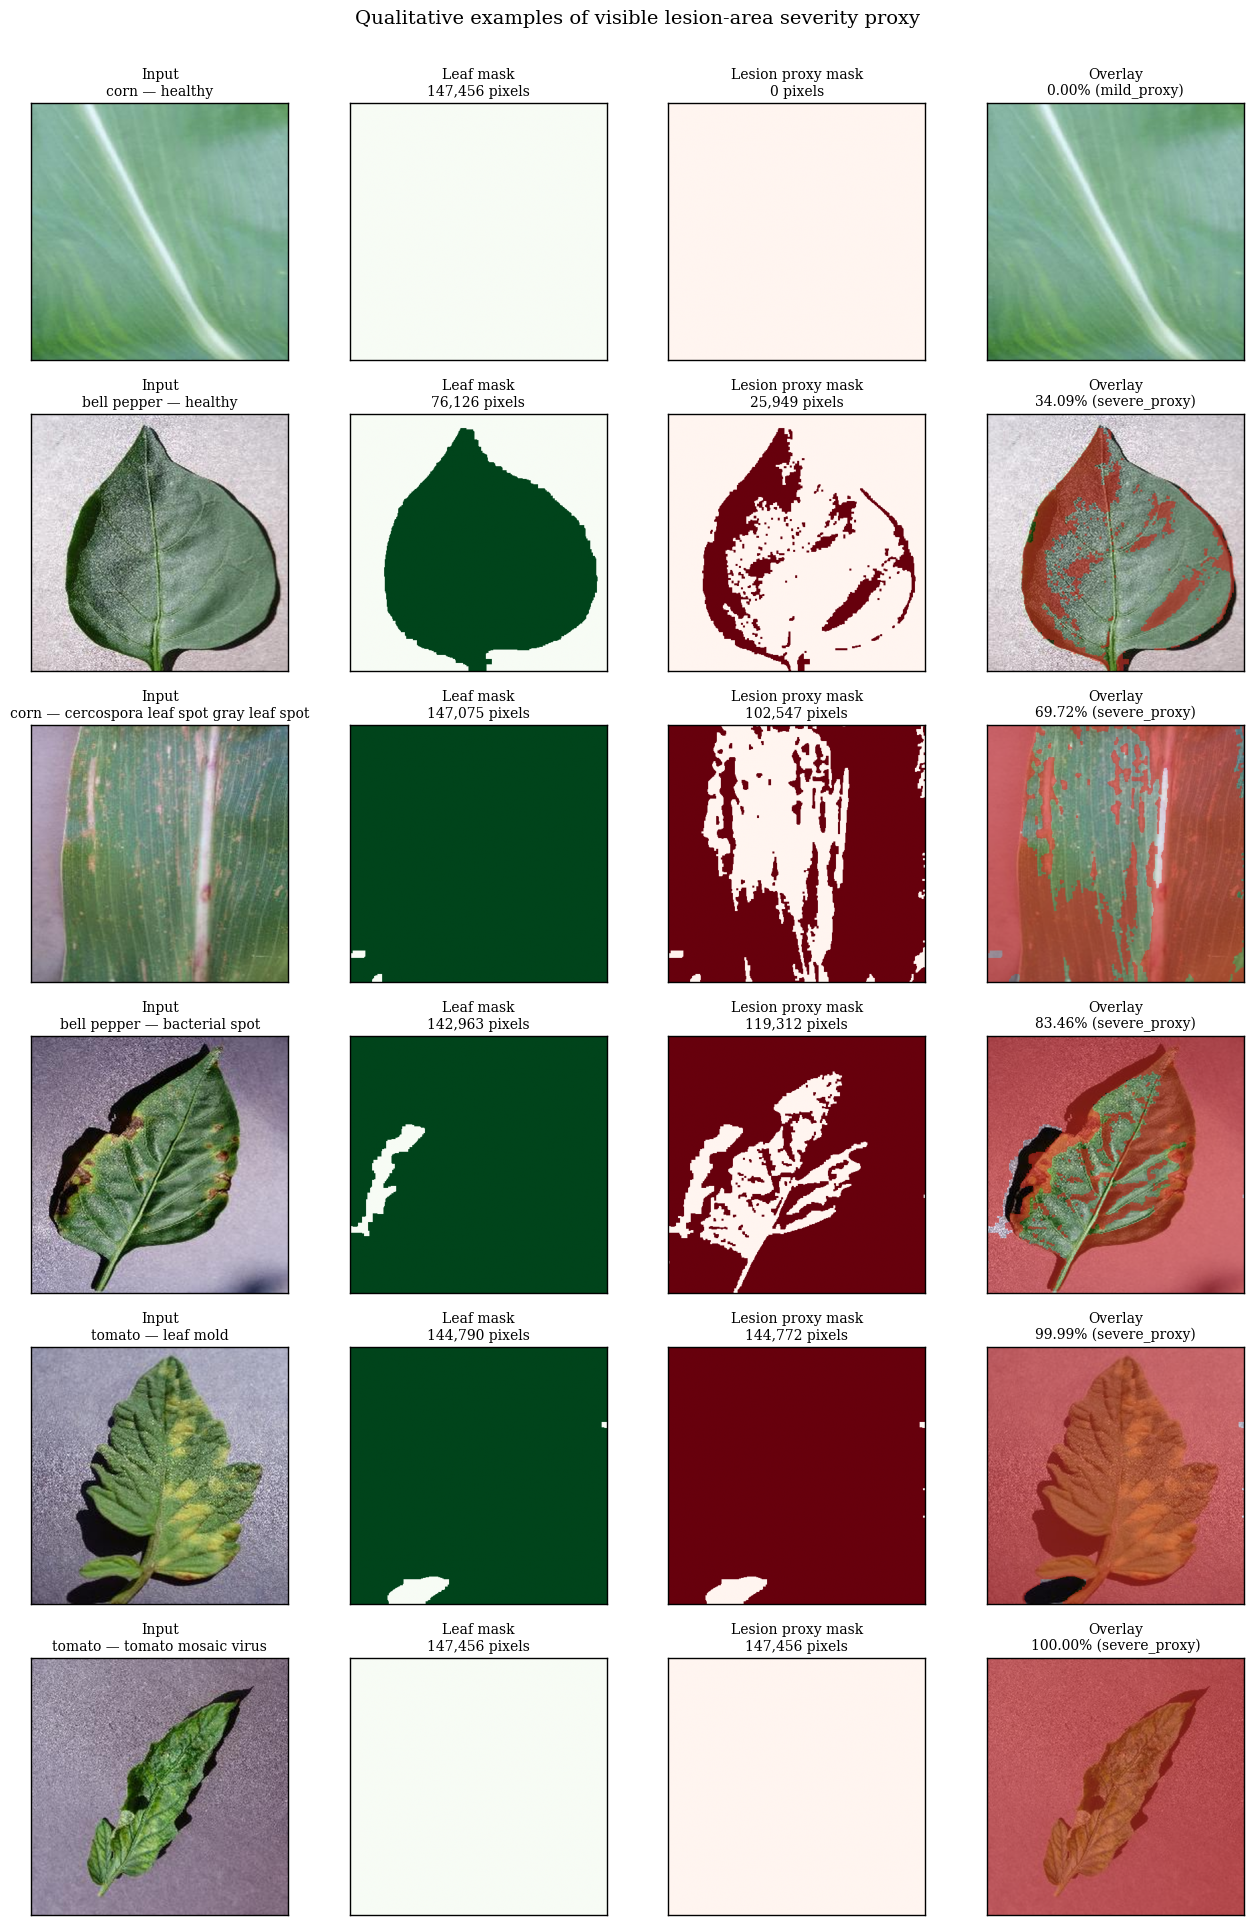

Saved: /kaggle/working/lesion_grounding_severity_proxy_outputs/figures/fig_01_qualitative_lesion_severity_proxy.png


In [12]:
display_df = (
    sample_results_df
    .dropna(subset=["severity_percent"])
    .sort_values("severity_percent")
)

selected_indices = np.linspace(
    0,
    len(display_df) - 1,
    num=min(6, len(display_df)),
    dtype=int
)

selected_examples = display_df.iloc[
    selected_indices
].reset_index(drop=True)

fig, axes = plt.subplots(
    len(selected_examples),
    4,
    figsize=(13, 3.2 * len(selected_examples))
)

if len(selected_examples) == 1:
    axes = np.array([axes])

for row_index, (_, row) in enumerate(
    selected_examples.iterrows()
):
    result = compute_severity_proxy(
        row["image_path"]
    )

    rgb_image = result["rgb_image"]
    leaf_mask = result["leaf_mask"]
    lesion_mask = result["lesion_mask"]

    overlay = rgb_image.copy()
    overlay[lesion_mask] = (
        0.45 * overlay[lesion_mask]
        + 0.55 * np.array([220, 45, 35])
    ).astype(np.uint8)

    title_label = (
        row["label"]
        .replace("__", " — ")
        .replace("_", " ")
    )

    axes[row_index, 0].imshow(rgb_image)
    axes[row_index, 0].set_title(
        f"Input\n{title_label}",
        fontsize=10
    )

    axes[row_index, 1].imshow(
        leaf_mask,
        cmap="Greens"
    )

    axes[row_index, 1].set_title(
        f"Leaf mask\n{result['leaf_pixels']:,} pixels",
        fontsize=10
    )

    axes[row_index, 2].imshow(
        lesion_mask,
        cmap="Reds"
    )

    axes[row_index, 2].set_title(
        f"Lesion proxy mask\n{result['lesion_pixels']:,} pixels",
        fontsize=10
    )

    axes[row_index, 3].imshow(overlay)

    axes[row_index, 3].set_title(
        f"Overlay\n{result['severity_percent']:.2f}% "
        f"({result['severity_category']})",
        fontsize=10
    )

    for axis in axes[row_index]:
        axis.set_xticks([])
        axis.set_yticks([])

        for spine in axis.spines.values():
            spine.set_linewidth(1.0)

fig.suptitle(
    "Qualitative examples of visible lesion-area severity proxy",
    y=1.002,
    fontsize=14
)

plt.tight_layout()

qualitative_png = (
    FIG_DIR / "fig_01_qualitative_lesion_severity_proxy.png"
)

qualitative_pdf = (
    FIG_DIR / "fig_01_qualitative_lesion_severity_proxy.pdf"
)

plt.savefig(
    qualitative_png,
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    qualitative_pdf,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("Saved:", qualitative_png)

In [13]:
severity_records = []

for _, row in tqdm(
    all_main19_df.iterrows(),
    total=len(all_main19_df),
    desc="Creating severity proxy manifest"
):
    try:
        result = compute_severity_proxy(
            row["image_path"]
        )

        severity_records.append({
            "image_path": row["image_path"],
            "label": row["label"],
            "crop": row.get("crop", ""),
            "disease": row.get("disease", ""),
            "final_split": row["final_split"],
            "leaf_pixels": result["leaf_pixels"],
            "lesion_pixels": result["lesion_pixels"],
            "visible_lesion_ratio": result["severity_ratio"],
            "visible_lesion_percent": result["severity_percent"],
            "severity_proxy_band": result["severity_category"],
            "mask_status": (
                "ok"
                if result["leaf_pixels"] > 0
                else "mask_failure"
            )
        })

    except Exception as error:
        severity_records.append({
            "image_path": row["image_path"],
            "label": row["label"],
            "crop": row.get("crop", ""),
            "disease": row.get("disease", ""),
            "final_split": row["final_split"],
            "leaf_pixels": np.nan,
            "lesion_pixels": np.nan,
            "visible_lesion_ratio": np.nan,
            "visible_lesion_percent": np.nan,
            "severity_proxy_band": "processing_failure",
            "mask_status": str(error)[:250]
        })

severity_manifest_df = pd.DataFrame(severity_records)

severity_manifest_path = (
    TABLE_DIR / "main19_visible_lesion_severity_proxy_manifest.csv"
)

severity_manifest_df.to_csv(
    severity_manifest_path,
    index=False
)

print("Severity manifest saved:", severity_manifest_path)
print("Images processed:", len(severity_manifest_df))

display(severity_manifest_df.head())

Creating severity proxy manifest:   0%|          | 0/26632 [00:00<?, ?it/s]

Severity manifest saved: /kaggle/working/lesion_grounding_severity_proxy_outputs/tables/main19_visible_lesion_severity_proxy_manifest.csv
Images processed: 26632


,image_path,label,crop,disease,final_split,leaf_pixels,lesion_pixels,visible_lesion_ratio,visible_lesion_percent,severity_proxy_band,mask_status
0,/kaggle/input/datasets/mohitsingh1804/plantvil...,corn__common_rust,corn,common_rust,train,102684,12873,0.12537,12.53652,moderate_proxy,ok
1,/kaggle/input/datasets/mohitsingh1804/plantvil...,tomato__bacterial_spot,tomato,bacterial_spot,train,97524,97125,0.99591,99.59087,severe_proxy,ok
2,/kaggle/input/datasets/mohitsingh1804/plantvil...,tomato__late_blight,tomato,late_blight,train,93926,85600,0.91136,91.13557,severe_proxy,ok
3,/kaggle/input/datasets/mohitsingh1804/plantvil...,tomato__bacterial_spot,tomato,bacterial_spot,train,71982,71932,0.99931,99.93054,severe_proxy,ok
4,/kaggle/input/datasets/mohitsingh1804/plantvil...,tomato__bacterial_spot,tomato,bacterial_spot,train,87830,87731,0.99887,99.88728,severe_proxy,ok


In [14]:
mask_failure_count = (
    severity_manifest_df["mask_status"] != "ok"
).sum()

valid_severity_df = severity_manifest_df[
    severity_manifest_df["mask_status"] == "ok"
].copy()

print("Total records:", len(severity_manifest_df))
print("Valid masks:", len(valid_severity_df))
print("Mask/processing failures:", mask_failure_count)

print("\nSeverity proxy band distribution:")
display(
    valid_severity_df[
        "severity_proxy_band"
    ].value_counts(dropna=False)
)

print("\nVisible lesion percentage summary:")
display(
    valid_severity_df[
        "visible_lesion_percent"
    ].describe(
        percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
    )
)

assert len(valid_severity_df) > 0
assert (
    valid_severity_df["visible_lesion_percent"] >= 0
).all()

assert (
    valid_severity_df["visible_lesion_percent"] <= 100
).all()

Total records: 26632
Valid masks: 26632
Mask/processing failures: 0

Severity proxy band distribution:


severity_proxy_band
severe_proxy      25067
moderate_proxy      950
mild_proxy          615
Name: count, dtype: int64


Visible lesion percentage summary:


count   26632.00000
mean       79.41570
std        27.93517
min         0.00000
1%          1.05838
5%         16.04296
25%        63.88699
50%        95.99533
75%        99.95996
95%       100.00000
99%       100.00000
max       100.00000
Name: visible_lesion_percent, dtype: float64

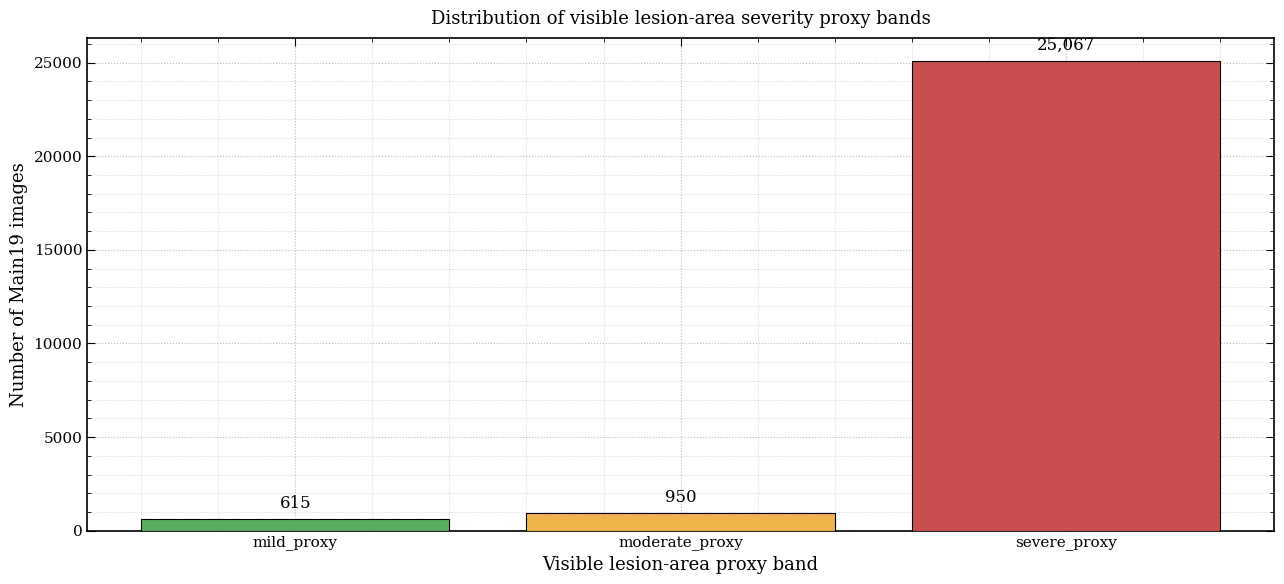

Saved: /kaggle/working/lesion_grounding_severity_proxy_outputs/figures/fig_02_severity_proxy_band_distribution.png


In [15]:
band_order = [
    "mild_proxy",
    "moderate_proxy",
    "severe_proxy"
]

band_counts = (
    valid_severity_df[
        "severity_proxy_band"
    ]
    .value_counts()
    .reindex(band_order, fill_value=0)
)

fig, ax = plt.subplots(figsize=(13, 6))

bar_colors = [
    "#5AAE61",
    "#F0B44D",
    "#C94F4F"
]

bars = ax.bar(
    band_counts.index,
    band_counts.values,
    color=bar_colors,
    edgecolor="black",
    linewidth=0.8,
    zorder=3
)

for bar, value in zip(bars, band_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + max(band_counts.values) * 0.015,
        f"{int(value):,}",
        ha="center",
        va="bottom",
        fontsize=12
    )

ax.set_xlabel("Visible lesion-area proxy band")
ax.set_ylabel("Number of Main19 images")

ax.set_title(
    "Distribution of visible lesion-area severity proxy bands",
    pad=10
)

paper_axes(ax)

plt.tight_layout()

band_distribution_png = (
    FIG_DIR / "fig_02_severity_proxy_band_distribution.png"
)

band_distribution_pdf = (
    FIG_DIR / "fig_02_severity_proxy_band_distribution.pdf"
)

plt.savefig(
    band_distribution_png,
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    band_distribution_pdf,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("Saved:", band_distribution_png)

In [16]:
class_severity_summary = (
    valid_severity_df
    .groupby(["label", "crop", "disease"], as_index=False)
    .agg(
        images=("image_path", "count"),
        mean_visible_lesion_percent=(
            "visible_lesion_percent",
            "mean"
        ),
        median_visible_lesion_percent=(
            "visible_lesion_percent",
            "median"
        ),
        standard_deviation=(
            "visible_lesion_percent",
            "std"
        ),
        mild_count=(
            "severity_proxy_band",
            lambda values: (values == "mild_proxy").sum()
        ),
        moderate_count=(
            "severity_proxy_band",
            lambda values: (values == "moderate_proxy").sum()
        ),
        severe_count=(
            "severity_proxy_band",
            lambda values: (values == "severe_proxy").sum()
        )
    )
)

class_severity_summary = class_severity_summary.sort_values(
    "median_visible_lesion_percent",
    ascending=False
)

class_summary_path = (
    TABLE_DIR / "severity_proxy_summary_by_class.csv"
)

class_severity_summary.to_csv(
    class_summary_path,
    index=False
)

display(class_severity_summary)
print("Saved:", class_summary_path)

,label,crop,disease,images,mean_visible_lesion_percent,median_visible_lesion_percent,standard_deviation,mild_count,moderate_count,severe_count
17,tomato__tomato_mosaic_virus,tomato,tomato_mosaic_virus,373,97.51897,100.00000,7.07136,0,0,373
15,tomato__spider_mites_two_spotted_spider_mite,tomato,spider_mites_two_spotted_spider_mite,1676,95.11522,99.87684,8.96836,0,0,1676
14,tomato__septoria_leaf_spot,tomato,septoria_leaf_spot,1771,84.04153,99.87098,22.65619,0,17,1754
9,tomato__bacterial_spot,tomato,bacterial_spot,2127,96.39212,99.84925,10.75525,0,2,2125
13,tomato__leaf_mold,tomato,leaf_mold,952,88.31024,99.74525,20.43931,0,1,951
8,potato__late_blight,potato,late_blight,1000,91.47743,99.60529,14.71041,0,0,1000
18,tomato__tomato_yellow_leaf_curl_virus,tomato,tomato_yellow_leaf_curl_virus,5357,81.88918,98.75007,24.16685,0,23,5334
10,tomato__early_blight,tomato,early_blight,1000,92.46962,98.07591,11.49892,0,1,999
12,tomato__late_blight,tomato,late_blight,1906,82.66236,97.16817,25.50880,8,82,1816
16,tomato__target_spot,tomato,target_spot,1404,89.21842,96.04276,13.40849,0,0,1404


Saved: /kaggle/working/lesion_grounding_severity_proxy_outputs/tables/severity_proxy_summary_by_class.csv


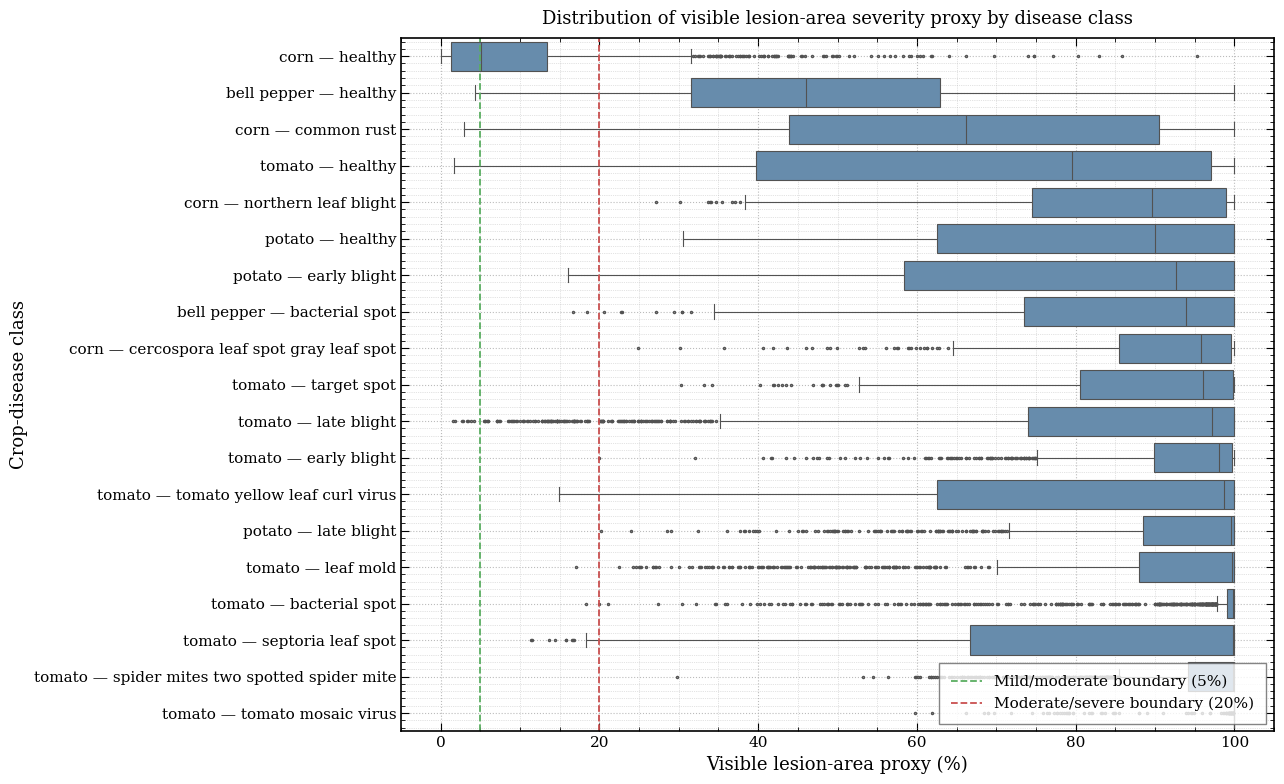

Saved: /kaggle/working/lesion_grounding_severity_proxy_outputs/figures/fig_03_severity_proxy_by_class_boxplot.png


In [17]:
plot_df = valid_severity_df.copy()

plot_df["readable_label"] = (
    plot_df["label"]
    .str.replace("__", " — ", regex=False)
    .str.replace("_", " ", regex=False)
)

label_order = (
    plot_df
    .groupby("readable_label")[
        "visible_lesion_percent"
    ]
    .median()
    .sort_values()
    .index
)

fig, ax = plt.subplots(figsize=(13, 8))

sns.boxplot(
    data=plot_df,
    x="visible_lesion_percent",
    y="readable_label",
    order=label_order,
    color="#5B8DB8",
    fliersize=1.5,
    linewidth=0.8,
    ax=ax
)

ax.axvline(
    5.0,
    linestyle="--",
    linewidth=1.3,
    color="#5AAE61",
    label="Mild/moderate boundary (5%)"
)

ax.axvline(
    20.0,
    linestyle="--",
    linewidth=1.3,
    color="#C94F4F",
    label="Moderate/severe boundary (20%)"
)

ax.set_xlabel("Visible lesion-area proxy (%)")
ax.set_ylabel("Crop-disease class")

ax.set_title(
    "Distribution of visible lesion-area severity proxy by disease class",
    pad=10
)

paper_axes(ax)

ax.legend(
    loc="lower right",
    fancybox=False,
    borderpad=0.8
)

plt.tight_layout()

class_boxplot_png = (
    FIG_DIR / "fig_03_severity_proxy_by_class_boxplot.png"
)

class_boxplot_pdf = (
    FIG_DIR / "fig_03_severity_proxy_by_class_boxplot.pdf"
)

plt.savefig(
    class_boxplot_png,
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    class_boxplot_pdf,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("Saved:", class_boxplot_png)

In [18]:
split_severity_summary = (
    valid_severity_df
    .groupby("final_split", as_index=False)
    .agg(
        images=("image_path", "count"),
        mean_visible_lesion_percent=(
            "visible_lesion_percent",
            "mean"
        ),
        median_visible_lesion_percent=(
            "visible_lesion_percent",
            "median"
        ),
        standard_deviation=(
            "visible_lesion_percent",
            "std"
        )
    )
)

split_severity_path = (
    TABLE_DIR / "severity_proxy_summary_by_split.csv"
)

split_severity_summary.to_csv(
    split_severity_path,
    index=False
)

display(split_severity_summary)
print("Saved:", split_severity_path)

,final_split,images,mean_visible_lesion_percent,median_visible_lesion_percent,standard_deviation
0,calibration,3197,79.64137,95.91630,27.78929
1,internal_test,5322,79.29728,95.52460,27.99506
2,train,18113,79.41067,96.19011,27.94454


Saved: /kaggle/working/lesion_grounding_severity_proxy_outputs/tables/severity_proxy_summary_by_split.csv


In [19]:
EXAMPLES_PER_BAND = 4

example_records = []

for band_name in band_order:
    band_df = valid_severity_df[
        valid_severity_df["severity_proxy_band"] == band_name
    ].copy()

    if len(band_df) == 0:
        continue

    sampled_band_df = band_df.sample(
        n=min(EXAMPLES_PER_BAND, len(band_df)),
        random_state=SEED
    )

    for _, row in sampled_band_df.iterrows():
        result = compute_severity_proxy(
            row["image_path"]
        )

        image_stem = (
            Path(row["image_path"]).stem
            .replace(" ", "_")
        )

        leaf_mask_path = (
            MASK_DIR / f"{image_stem}_leaf_mask.png"
        )

        lesion_mask_path = (
            MASK_DIR / f"{image_stem}_lesion_proxy_mask.png"
        )

        cv2.imwrite(
            str(leaf_mask_path),
            (
                result["leaf_mask"].astype(np.uint8)
                * 255
            )
        )

        cv2.imwrite(
            str(lesion_mask_path),
            (
                result["lesion_mask"].astype(np.uint8)
                * 255
            )
        )

        example_records.append({
            "image_path": row["image_path"],
            "label": row["label"],
            "severity_proxy_band": band_name,
            "visible_lesion_percent": (
                result["severity_percent"]
            ),
            "leaf_mask_file": str(leaf_mask_path),
            "lesion_proxy_mask_file": str(lesion_mask_path)
        })

example_masks_df = pd.DataFrame(example_records)

example_masks_path = (
    TABLE_DIR / "saved_severity_proxy_mask_examples.csv"
)

example_masks_df.to_csv(
    example_masks_path,
    index=False
)

display(example_masks_df)
print("Saved:", example_masks_path)

,image_path,label,severity_proxy_band,visible_lesion_percent,leaf_mask_file,lesion_proxy_mask_file
0,/kaggle/input/datasets/mohitsingh1804/plantvil...,corn__healthy,mild_proxy,1.77673,/kaggle/working/lesion_grounding_severity_prox...,/kaggle/working/lesion_grounding_severity_prox...
1,/kaggle/input/datasets/mohitsingh1804/plantvil...,corn__healthy,mild_proxy,0.38588,/kaggle/working/lesion_grounding_severity_prox...,/kaggle/working/lesion_grounding_severity_prox...
2,/kaggle/input/datasets/mohitsingh1804/plantvil...,corn__healthy,mild_proxy,0.63748,/kaggle/working/lesion_grounding_severity_prox...,/kaggle/working/lesion_grounding_severity_prox...
3,/kaggle/input/datasets/mohitsingh1804/plantvil...,corn__healthy,mild_proxy,0.05290,/kaggle/working/lesion_grounding_severity_prox...,/kaggle/working/lesion_grounding_severity_prox...
4,/kaggle/input/datasets/mohitsingh1804/plantvil...,bell_pepper__healthy,moderate_proxy,12.55128,/kaggle/working/lesion_grounding_severity_prox...,/kaggle/working/lesion_grounding_severity_prox...
5,/kaggle/input/datasets/mohitsingh1804/plantvil...,bell_pepper__healthy,moderate_proxy,11.93056,/kaggle/working/lesion_grounding_severity_prox...,/kaggle/working/lesion_grounding_severity_prox...
6,/kaggle/input/datasets/mohitsingh1804/plantvil...,tomato__healthy,moderate_proxy,14.01523,/kaggle/working/lesion_grounding_severity_prox...,/kaggle/working/lesion_grounding_severity_prox...
7,/kaggle/input/datasets/mohitsingh1804/plantvil...,corn__healthy,moderate_proxy,12.66362,/kaggle/working/lesion_grounding_severity_prox...,/kaggle/working/lesion_grounding_severity_prox...
8,/kaggle/input/datasets/mohitsingh1804/plantvil...,tomato__target_spot,severe_proxy,99.97159,/kaggle/working/lesion_grounding_severity_prox...,/kaggle/working/lesion_grounding_severity_prox...
9,/kaggle/input/datasets/mohitsingh1804/plantvil...,corn__common_rust,severe_proxy,97.27459,/kaggle/working/lesion_grounding_severity_prox...,/kaggle/working/lesion_grounding_severity_prox...


Saved: /kaggle/working/lesion_grounding_severity_proxy_outputs/tables/saved_severity_proxy_mask_examples.csv


In [20]:
limitations_text = """
# Visible Lesion-Area Severity Proxy: Interpretation and Limitations

## What this output measures
The severity value is the estimated percentage of the automatically identified
leaf region that contains colour/texture patterns considered lesion-like by
computer-vision heuristics.

## What it does not measure
- It is not expert-annotated lesion segmentation.
- It is not a clinical disease-stage label.
- It is not a validated crop-management treatment threshold.
- It does not account for hidden lesions, leaf age, whole-plant disease burden,
  temporal disease progression, or environmental conditions.

## Intended use
The proxy is used for exploratory lesion grounding, qualitative interpretation,
and future prioritisation of samples for expert review.

## Required caution
All reported proxy bands must be named mild_proxy, moderate_proxy, and
severe_proxy. They must not be reported as medically or agronomically validated
disease stages without external annotation and expert validation.
"""

limitations_path = (
    METADATA_DIR / "severity_proxy_limitations.md"
)

with open(limitations_path, "w") as file:
    file.write(limitations_text)

print(limitations_text)
print("Saved:", limitations_path)


# Visible Lesion-Area Severity Proxy: Interpretation and Limitations

## What this output measures
The severity value is the estimated percentage of the automatically identified
leaf region that contains colour/texture patterns considered lesion-like by
computer-vision heuristics.

## What it does not measure
- It is not expert-annotated lesion segmentation.
- It is not a clinical disease-stage label.
- It is not a validated crop-management treatment threshold.
- It does not account for hidden lesions, leaf age, whole-plant disease burden,
  temporal disease progression, or environmental conditions.

## Intended use
The proxy is used for exploratory lesion grounding, qualitative interpretation,
and future prioritisation of samples for expert review.

## Required caution
All reported proxy bands must be named mild_proxy, moderate_proxy, and
severe_proxy. They must not be reported as medically or agronomically validated
disease stages without external annotation and expert validation.



In [21]:
run_metadata = {
    "notebook": "09_lesion_grounding_severity_proxy",
    "completed_utc": datetime.now(timezone.utc).isoformat(),
    "input_images": int(len(all_main19_df)),
    "valid_proxy_masks": int(len(valid_severity_df)),
    "mask_or_processing_failures": int(mask_failure_count),
    "input_size": TARGET_SIZE,
    "severity_bands": {
        "mild_proxy": "< 5% visible lesion area",
        "moderate_proxy": "5% to <20% visible lesion area",
        "severe_proxy": ">=20% visible lesion area"
    },
    "method": (
        "Image-background separation and colour/texture-based lesion "
        "heuristics; not expert lesion segmentation."
    ),
    "ground_truth_severity_available": False,
    "python_version": platform.python_version(),
    "opencv_version": cv2.__version__,
    "numpy_version": np.__version__,
    "pandas_version": pd.__version__
}

run_metadata_path = (
    METADATA_DIR / "severity_proxy_run_metadata.json"
)

with open(run_metadata_path, "w") as file:
    json.dump(run_metadata, file, indent=2)

assert severity_manifest_path.exists()
assert class_summary_path.exists()
assert split_severity_path.exists()
assert example_masks_path.exists()
assert limitations_path.exists()
assert run_metadata_path.exists()

print(json.dumps(run_metadata, indent=2))

print("\n" + "=" * 78)
print("NOTEBOOK 09 COMPLETED")
print("=" * 78)

print("\nValid visible lesion-area proxy masks:", len(valid_severity_df))
print("Mask/processing failures:", mask_failure_count)
print("Severity manifest:", severity_manifest_path)
print("Output directory:", OUTPUT_DIR)

print("\nNext notebook:")
print("10_external_domain_shift_plantdoc")

{
  "notebook": "09_lesion_grounding_severity_proxy",
  "completed_utc": "2026-08-22T19:22:50.846242+00:00",
  "input_images": 26632,
  "valid_proxy_masks": 26632,
  "mask_or_processing_failures": 0,
  "input_size": 384,
  "severity_bands": {
    "mild_proxy": "< 5% visible lesion area",
    "moderate_proxy": "5% to <20% visible lesion area",
    "severe_proxy": ">=20% visible lesion area"
  },
  "method": "Image-background separation and colour/texture-based lesion heuristics; not expert lesion segmentation.",
  "ground_truth_severity_available": false,
  "python_version": "3.12.13",
  "opencv_version": "4.13.0",
  "numpy_version": "2.0.2",
  "pandas_version": "2.3.3"
}

NOTEBOOK 09 COMPLETED

Valid visible lesion-area proxy masks: 26632
Mask/processing failures: 0
Severity manifest: /kaggle/working/lesion_grounding_severity_proxy_outputs/tables/main19_visible_lesion_severity_proxy_manifest.csv
Output directory: /kaggle/working/lesion_grounding_severity_proxy_outputs

Next notebook:
1